# Prepocesamiento

LIBRERÍAS

In [15]:
!pip install plotly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [16]:
# 1. Carga del dataset
# =========================================================
DATA_PATH = "../data/raw/06-kickAutomotriz.csv"

df = pd.read_csv(DATA_PATH)

print("Primeras filas del dataset:")
display(df.head())

Primeras filas del dataset:


,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,0,1260144000,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,RED,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,0,1260144000,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,WHITE,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,0,1260144000,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,MAROON,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,0,1260144000,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,SILVER,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,0,1260144000,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,SILVER,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020


In [17]:
# Conversión del formato de fecha (YYYY-MM-DD)
df['PurchDate'] = pd.to_datetime(df['PurchDate'], unit='s')

# Visualización de los primeros registros
df.head()

,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,0,2009-12-07,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,RED,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,0,2009-12-07,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,WHITE,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,0,2009-12-07,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,MAROON,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,0,2009-12-07,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,SILVER,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,0,2009-12-07,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,SILVER,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020


In [18]:
# Seleccionando la variable que nos muestra cuántos vehículos son malas compras (1) y cuántos no (0)
df.IsBadBuy.value_counts()

IsBadBuy
0    64007
1     8976
Name: count, dtype: int64

In [19]:
# Creamos TARGET: 1 para compras exitosas, 0 para malas compras
df['TARGET'] = np.where(df['IsBadBuy'] == 0, 1, 0)

# Verificamos el conteo
df['TARGET'].value_counts()

TARGET
1    64007
0     8976
Name: count, dtype: int64

In [20]:
# Ahora veremos la proporción de compras exitosas (1) vs. compras riesgosas (0) en porcentaje
df["TARGET"].value_counts(normalize=True)

TARGET
1    0.877012
0    0.122988
Name: proportion, dtype: float64

## 4.1. Calidad

### 4.1.1. Nulos

In [21]:
# Eliminamos la columna original IsBadBuy para trabajar solo con TARGET
df.drop(columns=['IsBadBuy'], inplace=True)

# Verificamos que la columna ya no esté en el listado
df.columns

Index(['PurchDate', 'Auction', 'VehYear', 'VehicleAge', 'Make', 'Model',
       'Trim', 'SubModel', 'Color', 'Transmission', 'WheelTypeID', 'WheelType',
       'VehOdo', 'Nationality', 'Size', 'TopThreeAmericanName',
       'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice',
       'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice',
       'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice',
       'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice',
       'PRIMEUNIT', 'AUCGUART', 'BYRNO', 'VNZIP1', 'VNST', 'VehBCost',
       'IsOnlineSale', 'WarrantyCost', 'TARGET'],
      dtype='object')

In [22]:
# Veremos el porcentaje de valores nulos por columna (0.0 = 0% y 1.0 = 100%)
df.isnull().mean()

PurchDate                            0.000000
Auction                              0.000000
VehYear                              0.000000
VehicleAge                           0.000000
Make                                 0.000000
Model                                0.000000
Trim                                 0.032336
SubModel                             0.000110
Color                                0.000110
Transmission                         0.000123
WheelTypeID                          0.043421
WheelType                            0.043490
VehOdo                               0.000000
Nationality                          0.000069
Size                                 0.000069
TopThreeAmericanName                 0.000069
MMRAcquisitionAuctionAveragePrice    0.000247
MMRAcquisitionAuctionCleanPrice      0.000247
MMRAcquisitionRetailAveragePrice     0.000247
MMRAcquisitonRetailCleanPrice        0.000247
MMRCurrentAuctionAveragePrice        0.004316
MMRCurrentAuctionCleanPrice       

In [23]:
# 1. Eliminar columna con alta tasa de vacíos
# En este dataset, PRIMEUNIT tiene casi un 96% de nulos.
df.drop(columns=['PRIMEUNIT'], inplace=True)

# 2. Reemplazo de vacíos con constantes
# Para GENERO (en este caso Color o Transmission si tuvieran nulos), usamos 'D'
df['Color'] = df['Color'].fillna('D')

# Para variables de uso o conteo, usamos 0
# Aplicamos esto a WheelTypeID que es una categoría numérica con nulos
df['WheelTypeID'] = df['WheelTypeID'].fillna(0)

# 3. Reemplazo de vacíos con la mediana (Para variables continuas/numéricas)
# Aplicamos a las columnas de precios MMR y WarrantyCost si tuvieran nulos
df['MMRAcquisitionAuctionAveragePrice'] = df['MMRAcquisitionAuctionAveragePrice'].fillna(df['MMRAcquisitionAuctionAveragePrice'].median())
df['WarrantyCost'] = df['WarrantyCost'].fillna(df['WarrantyCost'].median())

# Verificamos que ya no existan nulos en las columnas tratadas
df.isnull().sum()

PurchDate                                0
Auction                                  0
VehYear                                  0
VehicleAge                               0
Make                                     0
Model                                    0
Trim                                  2360
SubModel                                 8
Color                                    0
Transmission                             9
WheelTypeID                              0
WheelType                             3174
VehOdo                                   0
Nationality                              5
Size                                     5
TopThreeAmericanName                     5
MMRAcquisitionAuctionAveragePrice        0
MMRAcquisitionAuctionCleanPrice         18
MMRAcquisitionRetailAveragePrice        18
MMRAcquisitonRetailCleanPrice           18
MMRCurrentAuctionAveragePrice          315
MMRCurrentAuctionCleanPrice            315
MMRCurrentRetailAveragePrice           315
MMRCurrentR

### 4.1.2 Duplicados

In [24]:
# 1. Homogenizar Transmisión (Evitar duplicados por escritura)
df['Transmission'] = df['Transmission'].str.upper()

# 2. Eliminar columnas con un solo valor (No aportan información)
# Si todos son 'FL' en VNST, no sirve para comparar.
if df['IsOnlineSale'].nunique() <= 1:
    df.drop(columns=['IsOnlineSale'], inplace=True)

# 3. Crear indicador de sobrecosto (KPI de Negocio)
df['Sobrecosto'] = df['VehBCost'] - df['MMRAcquisitionAuctionAveragePrice']

# 4. Limpieza final de nulos remanentes en WheelType
df['WheelType'] = df['WheelType'].fillna('Unknown')

In [25]:
# Eliminación por alta tasa de vacíos
df.drop(columns=['AUCGUART'], inplace=True)

### 4.1.3 Tipos

In [26]:
# Lista de categóricas para llenar con una constante
cols_categoricas = ['Trim', 'SubModel', 'Transmission', 'Nationality', 'Size', 'TopThreeAmericanName']
for col in cols_categoricas:
    df[col] = df[col].fillna('Unknown')

In [27]:
# 1. Limpiamos espacios invisibles en los nombres de las columnas
df.columns = df.columns.str.strip()

# 2. Definimos la lista con el nombre tal cual viene en el CSV (error ortográfico incluido)
cols_numericas = [
    'MMRAcquisitionAuctionAveragePrice',
    'MMRAcquisitionAuctionCleanPrice',
    'MMRAcquisitionRetailAveragePrice',
    'MMRAquisitonRetailCleanPrice',  # Nombre real en el CSV (sin la 'i')
    'MMRCurrentAuctionAveragePrice',
    'MMRCurrentAuctionCleanPrice',
    'MMRCurrentRetailAveragePrice',
    'MMRCurrentRetailCleanPrice',
    'VehBCost',
    'Sobrecosto'
]

# 3. Llenamos con la mediana solo si la columna existe en el DataFrame
for col in cols_numericas:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())
    else:
        print(f"Advertencia: La columna '{col}' no se encontró.")

# 4. Verificación final de nulos en estas columnas
print(df[df.columns.intersection(cols_numericas)].isnull().sum())

Advertencia: La columna 'MMRAquisitonRetailCleanPrice' no se encontró.
MMRAcquisitionAuctionAveragePrice    0
MMRAcquisitionAuctionCleanPrice      0
MMRAcquisitionRetailAveragePrice     0
MMRCurrentAuctionAveragePrice        0
MMRCurrentAuctionCleanPrice          0
MMRCurrentRetailAveragePrice         0
MMRCurrentRetailCleanPrice           0
VehBCost                             0
Sobrecosto                           0
dtype: int64


In [28]:
# 1. Identificamos qué columnas de nuestra lista están realmente presentes en el df
cols_presentes = [col for col in cols_numericas if col in df.columns]

# 2. Aplicamos el llenado solo a esas columnas
for col in cols_presentes:
    df[col] = df[col].fillna(df[col].median())

# 3. Verificamos si alguna de la lista original quedó fuera
cols_faltantes = set(cols_numericas) - set(cols_presentes)
print(f"Columnas no encontradas: {cols_faltantes}")

Columnas no encontradas: {'MMRAquisitonRetailCleanPrice'}


In [29]:
df.isnull().mean()

PurchDate                            0.000000
Auction                              0.000000
VehYear                              0.000000
VehicleAge                           0.000000
Make                                 0.000000
Model                                0.000000
Trim                                 0.000000
SubModel                             0.000000
Color                                0.000000
Transmission                         0.000000
WheelTypeID                          0.000000
WheelType                            0.000000
VehOdo                               0.000000
Nationality                          0.000000
Size                                 0.000000
TopThreeAmericanName                 0.000000
MMRAcquisitionAuctionAveragePrice    0.000000
MMRAcquisitionAuctionCleanPrice      0.000000
MMRAcquisitionRetailAveragePrice     0.000000
MMRAcquisitonRetailCleanPrice        0.000247
MMRCurrentAuctionAveragePrice        0.000000
MMRCurrentAuctionCleanPrice       

In [30]:
df.describe()

,PurchDate,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VehBCost,IsOnlineSale,WarrantyCost,TARGET,Sobrecosto
count,72983,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000,72965.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000
mean,2010-01-10 02:51:53.590836224,2005.343052,4.176644,1.429415,71499.995917,6128.901347,7373.618610,8497.021252,9850.928240,6131.778812,7390.346546,8775.521669,10145.202376,26345.842155,58043.059945,6729.222696,0.025280,1276.580985,0.877012,603.804037
min,2009-01-05 00:00:00,2001.000000,0.000000,0.000000,4825.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,835.000000,2764.000000,1.000000,0.000000,462.000000,0.000000,-10343.000000
25%,2009-07-20 00:00:00,2004.000000,3.000000,1.000000,61837.000000,4273.000000,5407.000000,6281.000000,7493.000000,4285.000000,5425.000000,6550.000000,7796.000000,17212.000000,32124.000000,5435.000000,0.000000,837.000000,1.000000,-266.500000
50%,2010-01-21 00:00:00,2005.000000,4.000000,1.000000,73361.000000,6097.000000,7303.000000,8444.000000,9789.000000,6062.000000,7313.000000,8729.000000,10103.000000,19662.000000,73108.000000,6700.000000,0.000000,1155.000000,1.000000,620.000000
75%,2010-07-14 00:00:00,2007.000000,5.000000,2.000000,82436.000000,7765.000000,9021.000000,10650.000000,12088.000000,7732.000000,9006.000000,10897.000000,12308.000000,22808.000000,80022.000000,7900.000000,0.000000,1623.000000,1.000000,1484.000000
max,2010-12-30 00:00:00,2010.000000,9.000000,3.000000,115717.000000,35722.000000,36859.000000,39080.000000,41482.000000,35722.000000,36859.000000,39080.000000,41062.000000,99761.000000,99224.000000,45469.000000,1.000000,7498.000000,1.000000,12045.000000
std,NaN,1.731252,1.712210,0.593878,14578.913128,2461.689193,2722.156458,3155.896142,3385.789541,2429.312427,2680.450317,3084.027307,3303.104046,25717.351219,26151.640415,1764.140437,0.156975,598.846788,0.328425,1515.940483


In [31]:
# 1. ELIMINACIÓN DE REGISTROS IMPOSIBLES (Ruido)
# Eliminamos filas donde el costo es 1 USD o el kilometraje es sospechosamente bajo
df = df[df['VehBCost'] > 100]
df = df[df['VehOdo'] > 100]

# 2. TRATAMIENTO DE CEROS EN PRECIOS (Imputación con Mediana)
# Identificamos columnas de precios que tienen ceros en lugar de nulos
cols_precios = [c for c in df.columns if 'MMR' in c]

for col in cols_precios:
    # Calculamos la mediana solo de los valores mayores a cero
    mediana_real = df[df[col] > 0][col].median()
    # Reemplazamos los ceros por esa mediana
    df[col] = df[col].replace(0, mediana_real)

# 3. RECALCULO DE VARIABLES DERIVADAS
# Actualizamos el Sobrecosto con los precios ya limpios
df['Sobrecosto'] = df['VehBCost'] - df['MMRAcquisitionAuctionAveragePrice']

# 4. VERIFICACIÓN FINAL
print(f"Registros restantes: {len(df)}")
print(f"Mínimo de VehBCost: {df.VehBCost.min()}")

Registros restantes: 72982
Mínimo de VehBCost: 225.0


In [32]:
df.describe()

,PurchDate,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VehBCost,IsOnlineSale,WarrantyCost,TARGET,Sobrecosto
count,72982,72982.000000,72982.000000,72982.000000,72982.000000,72982.000000,72982.000000,72982.000000,72964.000000,72982.000000,72982.000000,72982.000000,72982.000000,72982.000000,72982.000000,72982.000000,72982.000000,72982.000000,72982.000000,72982.000000
mean,2010-01-10 02:58:55.184018176,2005.343112,4.176591,1.429435,71499.569223,6198.566825,7443.809789,8593.325669,9962.636232,6173.748198,7428.292867,8835.997753,10215.073772,26344.836220,58042.690335,6729.314886,0.025280,1276.576690,0.877024,530.748061
min,2009-01-05 00:00:00,2001.000000,0.000000,0.000000,4825.000000,884.000000,1.000000,1455.000000,1662.000000,369.000000,1.000000,899.000000,1034.000000,835.000000,2764.000000,225.000000,0.000000,462.000000,0.000000,-18333.000000
25%,2009-07-20 00:00:00,2004.000000,3.000000,1.000000,61837.000000,4358.000000,5489.000000,6386.000000,7593.000000,4331.000000,5471.000000,6607.000000,7863.000000,17212.000000,32124.000000,5435.000000,0.000000,837.000000,1.000000,-278.000000
50%,2010-01-21 00:00:00,2005.000000,4.000000,1.000000,73361.000000,6136.000000,7344.000000,8482.000000,9837.000000,6070.000000,7316.000000,8746.000000,10106.000000,19662.000000,73108.000000,6700.000000,0.000000,1155.000000,1.000000,600.000000
75%,2010-07-14 00:00:00,2007.000000,5.000000,2.000000,82435.000000,7765.000000,9021.000000,10650.000000,12088.000000,7732.000000,9006.000000,10897.000000,12308.000000,22808.000000,80022.000000,7900.000000,0.000000,1623.000000,1.000000,1455.000000
max,2010-12-30 00:00:00,2010.000000,9.000000,3.000000,115717.000000,35722.000000,36859.000000,39080.000000,41482.000000,35722.000000,36859.000000,39080.000000,41062.000000,99761.000000,99224.000000,45469.000000,1.000000,7498.000000,1.000000,11926.000000
std,NaN,1.731189,1.712164,0.593859,14578.557277,2372.505359,2624.090023,3021.756810,3217.075927,2374.881222,2626.861457,2995.903650,3192.882884,25716.091522,26151.628954,1763.976710,0.156976,598.849767,0.328411,1379.372409


### 4.1.4 Limpieza de outliers y errores

In [33]:
# Eliminamos registros con costos de adquisición demasiado bajos (errores de carga)
# Un vehículo de subasta por menos de 500 USD suele ser chatarra o error.
df = df[df['VehBCost'] > 500]

# Eliminamos registros donde el Sobrecosto sea una anomalía extrema
# (Pagar 18k menos que el mercado o 12k más sugiere datos corruptos)
df = df[(df['Sobrecosto'] > -5000) & (df['Sobrecosto'] < 8000)]

In [34]:
# Columnas MMR a sanear
cols_mmr = [c for c in df.columns if 'MMR' in c]

for col in cols_mmr:
    # Reemplazamos valores sospechosos (0 o 1) por NaN para que fillna trabaje
    df.loc[df[col] <= 1, col] = None

    # Llenamos nulos con la mediana del año del vehículo (más preciso)
    df[col] = df.groupby('VehYear')[col].transform(lambda x: x.fillna(x.median()))

    # Si aún quedan nulos (años con pocos datos), usamos la mediana global
    df[col] = df[col].fillna(df[col].median())

# Recalculamos el Sobrecosto final con datos limpios
df['Sobrecosto'] = df['VehBCost'] - df['MMRAcquisitionAuctionAveragePrice']

In [35]:
df.describe()

,PurchDate,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VehBCost,IsOnlineSale,WarrantyCost,TARGET,Sobrecosto
count,72796,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000
mean,2010-01-10 04:40:15.693169920,2005.338700,4.181287,1.430408,71487.010880,6175.233461,7430.420861,8568.925435,9936.066597,6152.222155,7415.870652,8812.911781,10189.707814,26363.589689,58034.415270,6723.940821,0.025290,1276.447566,0.877273,548.707360
min,2009-01-05 00:00:00,2001.000000,0.000000,0.000000,5368.000000,884.000000,1076.000000,1455.000000,1662.000000,369.000000,494.000000,899.000000,1034.000000,835.000000,2764.000000,1400.000000,0.000000,462.000000,0.000000,-4995.000000
25%,2009-07-20 00:00:00,2004.000000,3.000000,1.000000,61822.000000,4353.750000,5499.000000,6378.000000,7588.000000,4327.000000,5476.000000,6603.000000,7858.000000,17212.000000,32124.000000,5430.000000,0.000000,837.000000,1.000000,-271.250000
50%,2010-01-21 00:00:00,2005.000000,4.000000,1.000000,73341.000000,6136.000000,7344.000000,8482.000000,9837.000000,6070.000000,7316.000000,8746.000000,10106.000000,19662.000000,73108.000000,6700.000000,0.000000,1155.000000,1.000000,604.000000
75%,2010-07-14 00:00:00,2007.000000,5.000000,2.000000,82415.250000,7753.000000,9007.000000,10632.000000,12070.000000,7720.250000,8991.000000,10878.000000,12298.000000,22808.000000,80022.000000,7900.000000,0.000000,1623.000000,1.000000,1458.000000
max,2010-12-30 00:00:00,2010.000000,9.000000,3.000000,115717.000000,35722.000000,36859.000000,39080.000000,41482.000000,35722.000000,36859.000000,39080.000000,41062.000000,99761.000000,99224.000000,38785.000000,1.000000,7498.000000,1.000000,7226.000000
std,NaN,1.730773,1.711392,0.593928,14567.016253,2326.039402,2554.899659,2982.253555,3172.999088,2334.824339,2564.262227,2959.951559,3152.155936,25728.670725,26153.087862,1756.047624,0.157005,599.070352,0.328125,1328.010509


In [36]:
from sklearn.preprocessing import LabelEncoder

# Lista de columnas de texto que el modelo debe entender
cols_categoricas = ['Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission',
                   'WheelType', 'Nationality', 'Size', 'TopThreeAmericanName']

le = LabelEncoder()

for col in cols_categoricas:
    # Convertimos cada texto en un número único
    df[col] = le.fit_transform(df[col].astype(str))

# Verificamos que ahora todo el dataframe sea numérico
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72796 entries, 0 to 72982
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   PurchDate                          72796 non-null  datetime64[ns]
 1   Auction                            72796 non-null  object        
 2   VehYear                            72796 non-null  int64         
 3   VehicleAge                         72796 non-null  int64         
 4   Make                               72796 non-null  int64         
 5   Model                              72796 non-null  int64         
 6   Trim                               72796 non-null  int64         
 7   SubModel                           72796 non-null  int64         
 8   Color                              72796 non-null  int64         
 9   Transmission                       72796 non-null  int64         
 10  WheelTypeID                        7279

## 4.2. Descriptivas

### 4.2.1 Descripcion

In [37]:
df.describe()

,PurchDate,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,WheelTypeID,...,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VehBCost,IsOnlineSale,WarrantyCost,TARGET,Sobrecosto
count,72796,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,...,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000
mean,2010-01-10 04:40:15.693169920,2005.338700,4.181287,8.571803,507.137343,58.090101,307.409377,8.688911,0.035634,1.430408,...,7415.870652,8812.911781,10189.707814,26363.589689,58034.415270,6723.940821,0.025290,1276.447566,0.877273,548.707360
min,2009-01-05 00:00:00,2001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,494.000000,899.000000,1034.000000,835.000000,2764.000000,1400.000000,0.000000,462.000000,0.000000,-4995.000000
25%,2009-07-20 00:00:00,2004.000000,3.000000,4.000000,303.000000,23.000000,150.000000,2.000000,0.000000,1.000000,...,5476.000000,6603.000000,7858.000000,17212.000000,32124.000000,5430.000000,0.000000,837.000000,1.000000,-271.250000
50%,2010-01-21 00:00:00,2005.000000,4.000000,5.000000,475.000000,55.000000,240.000000,8.000000,0.000000,1.000000,...,7316.000000,8746.000000,10106.000000,19662.000000,73108.000000,6700.000000,0.000000,1155.000000,1.000000,604.000000
75%,2010-07-14 00:00:00,2007.000000,5.000000,12.000000,750.000000,84.000000,398.000000,14.000000,0.000000,2.000000,...,8991.000000,10878.000000,12298.000000,22808.000000,80022.000000,7900.000000,0.000000,1623.000000,1.000000,1458.000000
max,2010-12-30 00:00:00,2010.000000,9.000000,31.000000,1046.000000,133.000000,852.000000,16.000000,2.000000,3.000000,...,36859.000000,39080.000000,41062.000000,99761.000000,99224.000000,38785.000000,1.000000,7498.000000,1.000000,7226.000000
std,NaN,1.730773,1.711392,7.434062,280.604353,36.613067,195.924959,5.494360,0.186042,0.593928,...,2564.262227,2959.951559,3152.155936,25728.670725,26153.087862,1756.047624,0.157005,599.070352,0.328125,1328.010509


### 4.2.2. Value counts

In [38]:
# 1. Ver el desbalance del TARGET
print(df['TARGET'].value_counts(normalize=True))

# 2. Ver las marcas más frecuentes
print(df['Make'].value_counts().head(10))

# 3. Detectar categorías irrelevantes o "ruido"
print(df['Size'].value_counts())

TARGET
1    0.877273
0    0.122727
Name: proportion, dtype: float64
Make
3     17240
5     12890
6     11232
4      8835
23     4256
13     2483
24     2163
20     2075
9      1811
12     1633
Name: count, dtype: int64
Size
5     30762
2      8845
6      8061
0      7205
12     5845
4      3124
7      2244
9      1908
1      1732
3      1427
8       862
10      776
11        5
Name: count, dtype: int64


## 4.2.3. Balanceo de clases

Conteo absoluto:
TARGET
1    63862
0     8934
Name: count, dtype: int64

Conteo porcentual (Balance de clases):
TARGET
1    87.727348
0    12.272652
Name: proportion, dtype: float64


/var/folders/d7/ftvxh7c91ybfj1k_y_h9vz0c0000gn/T/ipykernel_58259/4147229852.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=df, palette='viridis')


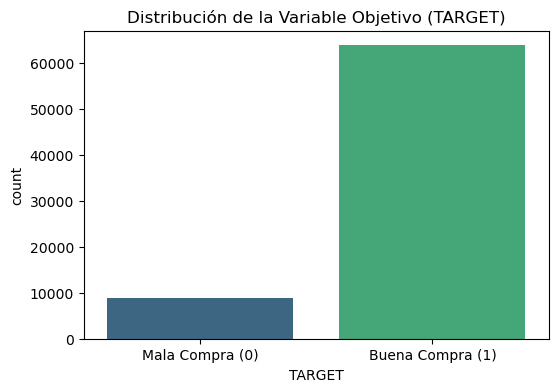

In [39]:
# 1. Conteo absoluto y porcentual del TARGET
print("Conteo absoluto:")
print(df['TARGET'].value_counts())

print("\nConteo porcentual (Balance de clases):")
print(df['TARGET'].value_counts(normalize=True) * 100)

# 2. Visualización rápida para el reporte
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=df, palette='viridis')
plt.title('Distribución de la Variable Objetivo (TARGET)')
plt.xticks([0, 1], ['Mala Compra (0)', 'Buena Compra (1)'])
plt.show()

## 4.3. Visualizaciones

### 4.3.1 Histogramas

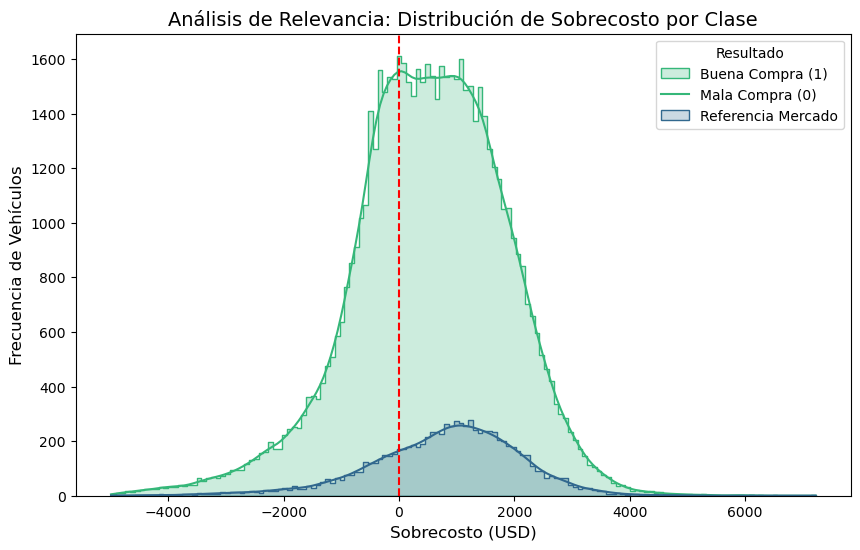

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la figura
plt.figure(figsize=(10, 6))

# Histograma de Sobrecosto segmentado por TARGET
sns.histplot(data=df, x='Sobrecosto', hue='TARGET', kde=True, element="step", palette="viridis")

# Línea de referencia en 0 (donde el costo iguala al mercado)
plt.axvline(0, color='red', linestyle='--', label='Costo = Mercado')

plt.title('Análisis de Relevancia: Distribución de Sobrecosto por Clase', fontsize=14)
plt.xlabel('Sobrecosto (USD)', fontsize=12)
plt.ylabel('Frecuencia de Vehículos', fontsize=12)
plt.legend(title='Resultado', labels=['Buena Compra (1)', 'Mala Compra (0)', 'Referencia Mercado'])

plt.show()

### 4.3.2. Diagrama de Barras

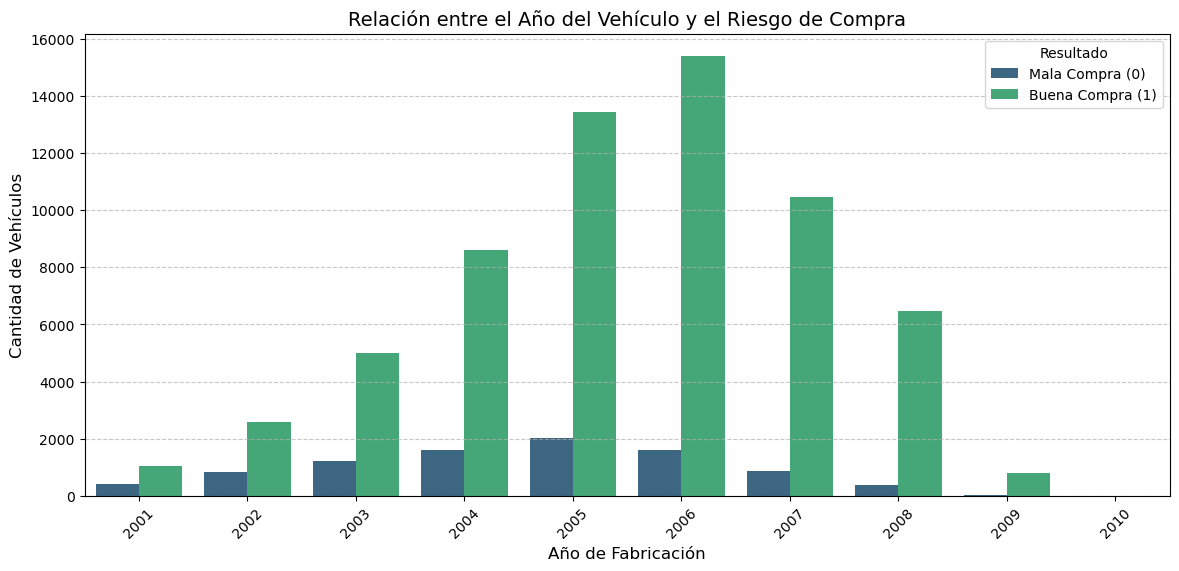

In [41]:
plt.figure(figsize=(14, 6))

# Graficamos la cantidad de vehículos por año, segmentado por TARGET
# Usamos un gráfico de barras apiladas o agrupadas
ax = sns.countplot(data=df, x='VehYear', hue='TARGET', palette='viridis')

# Personalización para que se vea profesional en tu reporte
plt.title('Relación entre el Año del Vehículo y el Riesgo de Compra', fontsize=14)
plt.xlabel('Año de Fabricación', fontsize=12)
plt.ylabel('Cantidad de Vehículos', fontsize=12)
plt.legend(title='Resultado', labels=['Mala Compra (0)', 'Buena Compra (1)'])
plt.xticks(rotation=45)

# Añadimos una cuadrícula ligera para facilitar la lectura
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### 4.3.3. Mapa de calor

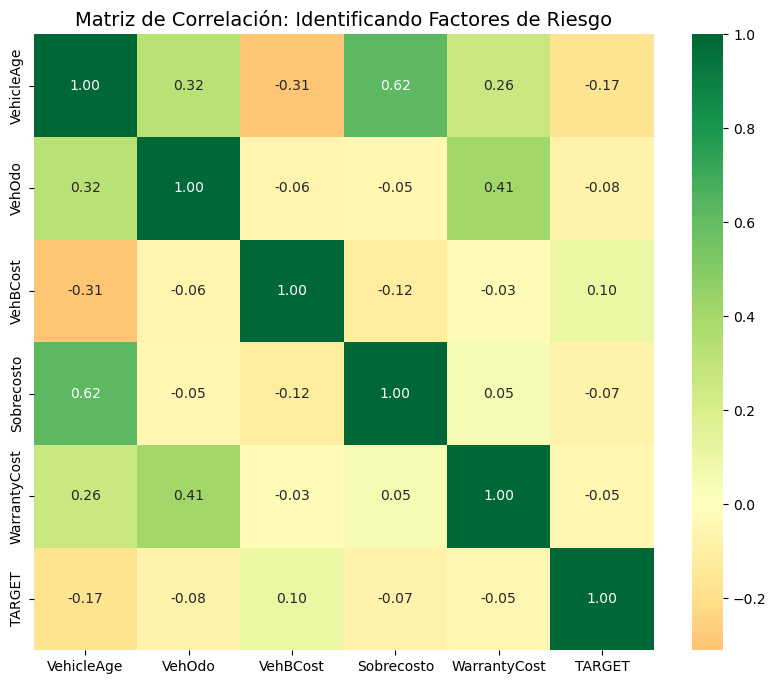

In [42]:
# 1. Seleccionamos las variables numéricas clave para el negocio
cols_interes = [
    'VehicleAge', 'VehOdo', 'VehBCost', 
    'Sobrecosto', 'WarrantyCost', 'TARGET'
]

# 2. Calculamos la correlación de Pearson
corr = df[cols_interes].corr()

# 3. Visualizamos con un Mapa de Calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title('Matriz de Correlación: Identificando Factores de Riesgo', fontsize=14)
plt.show()

### 4.3.4. Target Vs Variables

/var/folders/d7/ftvxh7c91ybfj1k_y_h9vz0c0000gn/T/ipykernel_58259/2715347712.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y='VehicleAge', data=df, ax=axes[0], palette='coolwarm')
/var/folders/d7/ftvxh7c91ybfj1k_y_h9vz0c0000gn/T/ipykernel_58259/2715347712.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y='Sobrecosto', data=df, ax=axes[1], palette='coolwarm')


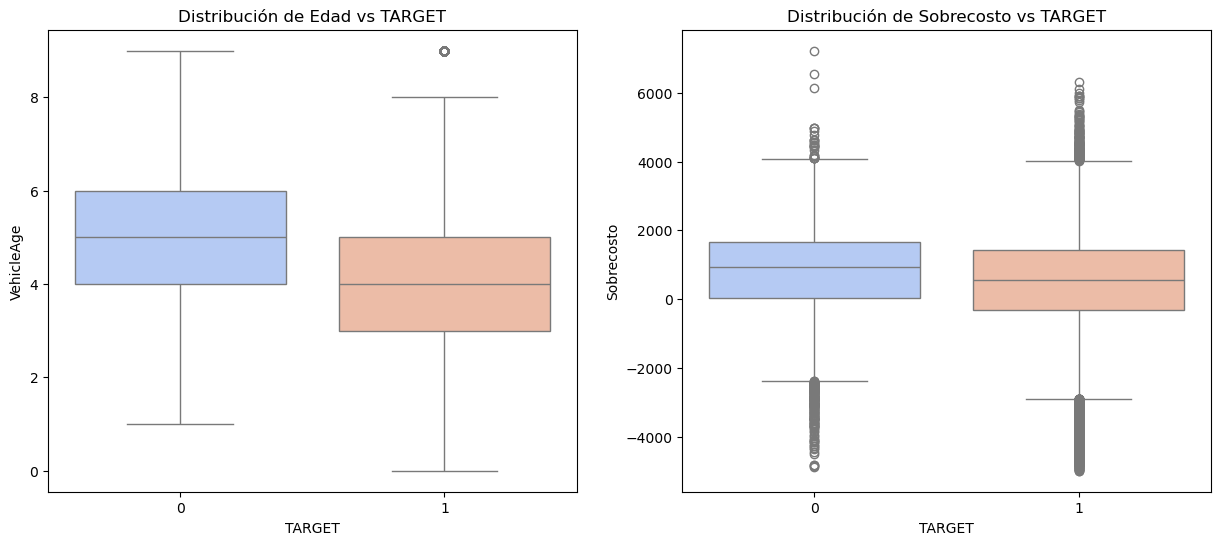

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot para Edad del Vehículo
sns.boxplot(x='TARGET', y='VehicleAge', data=df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Distribución de Edad vs TARGET')

# Boxplot para Sobrecosto
sns.boxplot(x='TARGET', y='Sobrecosto', data=df, ax=axes[1], palette='coolwarm')
axes[1].set_title('Distribución de Sobrecosto vs TARGET')

plt.show()